<div style="background:#E9FFF6; color:#440404; padding:8px; border-radius: 4px; text-align: center; font-weight: 500;">IFN619 - Data Analytics for Strategic Decision Makers</div>

# IFN619 :: C4 - Machine Learning - Tutorial Exercises

Ensure that you have worked through the lecture notebook before doing this tutorial, as the exercises below will build on what you did in the lecture notebook.

In [1]:
from sklearn.preprocessing import minmax_scale

from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import pandas as pd
import plotly.express as px


### K-means algorithm Exercises

1. Load the [Queensland Ambulance Service Locations and Coordinates Data](https://data.qld.gov.au/dataset/679424b4-ccf8-46cd-8e0b-f16c49572dbb) into a dataframe
2. Load the data into a dataframe
3. Perform a k-means clustering based on coordinates (start with 2 clusters)
4. Visualise on a map (check out [Scatter Plots on Tile Maps in Python](https://plotly.com/python/tile-scatter-maps/) and [Plotly Express `scatter_map`](https://plotly.com/python-api-reference/generated/plotly.express.scatter_map.html). 
5. Try increasing the number of clusters to identify potentially meaningful groupings

#### Load the data

In [2]:
# Load the data
qas_df = pd.read_csv("https://www.data.qld.gov.au/datastore/dump/83360397-4dcb-495c-a9c8-342a5ef6b5aa?bom=True", index_col="_id")
qas_df

,Entity Name,X Coordinates,Y Coordinates
_id,,,
1,Agnes Water,151.864227,-24.240932
2,Alpha,146.636754,-23.655066
3,Aramac,145.242361,-22.968175
4,Archerfield Helicopter,152.999900,-27.566600
5,Ashgrove,152.968333,-27.448611
...,...,...,...
286,Wynnum,153.182100,-27.465154
287,Yandina,152.960848,-26.556462
288,Yarrabah,145.865235,-16.907491


#### Create the model and fit to relevant data

The reason for changing the `cluster2` datatype to category below is for visualisation purposes. If a column is identified as numeric, `plotly` will treat it as continuous by default. In this context, clusters are distinct categories rather than a continuous range.

In [3]:
clst2 = KMeans(n_clusters=2, random_state=0).fit(qas_df[['X Coordinates','Y Coordinates']])
qas_df['cluster2'] = clst2.labels_

# Convert 'cluster2' to a categorical type
qas_df['cluster2'] = qas_df['cluster2'].astype('category')

qas_df

,Entity Name,X Coordinates,Y Coordinates,cluster2
_id,,,,
1,Agnes Water,151.864227,-24.240932,1
2,Alpha,146.636754,-23.655066,0
3,Aramac,145.242361,-22.968175,0
4,Archerfield Helicopter,152.999900,-27.566600,1
5,Ashgrove,152.968333,-27.448611,1
...,...,...,...,...
286,Wynnum,153.182100,-27.465154,1
287,Yandina,152.960848,-26.556462,1
288,Yarrabah,145.865235,-16.907491,0


#### Visualise the clusters

In [4]:
# find the central point on the map
lat_center = (min(qas_df['Y Coordinates']) + max(qas_df['Y Coordinates']))/2
lon_center = (min(qas_df['X Coordinates']) + max(qas_df['X Coordinates']))/2

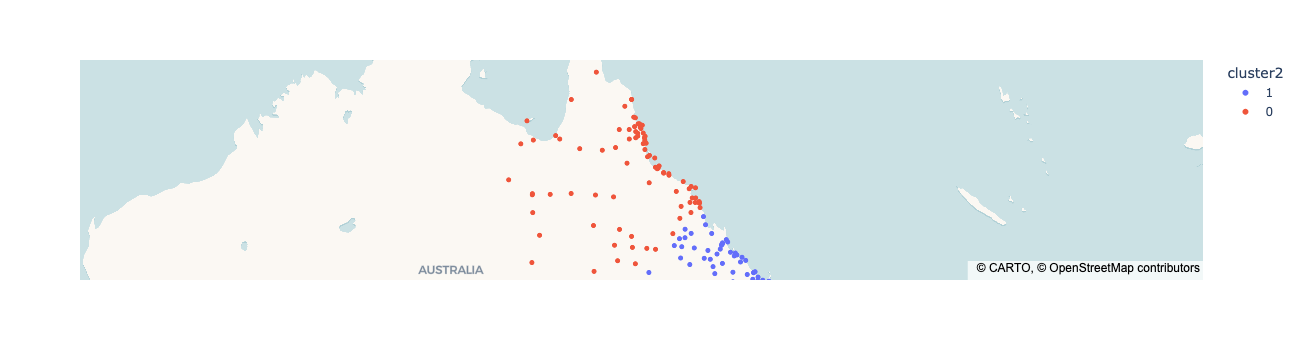

In [5]:
qas_map = px.scatter_map(qas_df, 
    lat="Y Coordinates", 
    lon="X Coordinates",
    color="cluster2",
    center = {'lat':lat_center,
              'lon':lon_center},
    zoom = 3.6) 

qas_map.show()

#### Try more clusters

In [6]:
clst6 = KMeans(n_clusters=6, random_state=0).fit(qas_df[['X Coordinates','Y Coordinates']])
qas_df['cluster6'] = clst6.labels_
qas_df['cluster6'] = qas_df['cluster6'].astype('category')
qas_df

,Entity Name,X Coordinates,Y Coordinates,cluster2,cluster6
_id,,,,,
1,Agnes Water,151.864227,-24.240932,1,5
2,Alpha,146.636754,-23.655066,0,2
3,Aramac,145.242361,-22.968175,0,2
4,Archerfield Helicopter,152.999900,-27.566600,1,4
5,Ashgrove,152.968333,-27.448611,1,4
...,...,...,...,...,...
286,Wynnum,153.182100,-27.465154,1,4
287,Yandina,152.960848,-26.556462,1,4
288,Yarrabah,145.865235,-16.907491,0,0


#### Visualise

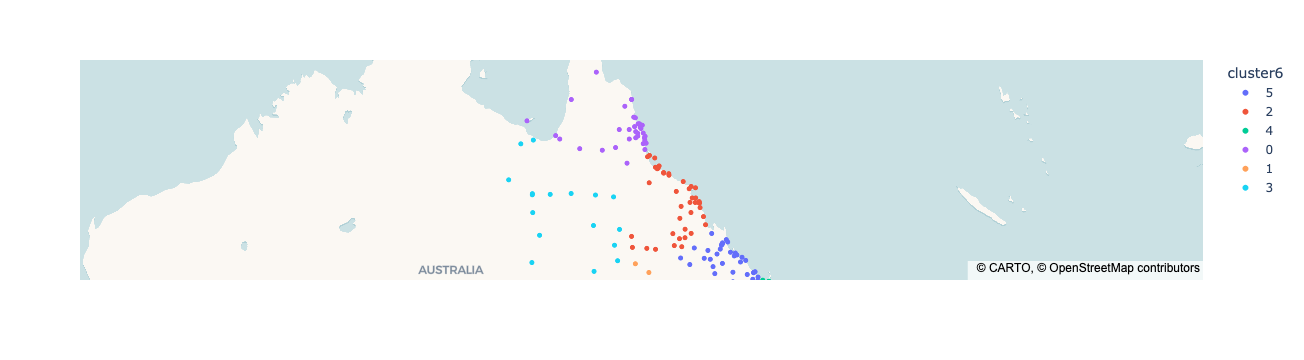

In [7]:
qas_map = px.scatter_map(qas_df, 
    lat="Y Coordinates", 
    lon="X Coordinates",
    color="cluster6",
    hover_name = "Entity Name",
    center = {'lat':lat_center,
              'lon':lon_center},
    zoom = 3.6)
qas_map.show()


### Linear Regression algorithm

1. Load the [Great Barrier Reef Carbon Dioxide Measurements](https://www.csiro.au/en/education/Resources/Educational-datasets/GBR-Carbon-Study) data located in the data folder (`gbr.csv`)
2. Perform linear regression to predict CO2
3. Experiment with predictions (increase the temperature to see what happens)


#### Load the data

In [9]:
lr_df = pd.read_csv('./data/gbr.csv')
lr_df

,co2,pressure,temp,sea_surface_temp,salinity
0,413.36,1014.35,26.06,25.837,35.484
1,404.38,1009.49,27.83,27.639,35.343
2,458.92,1011.31,26.65,26.365,36.104
3,444.49,1010.93,30.07,29.821,34.839
4,444.45,1006.38,30.24,29.900,33.885
...,...,...,...,...,...
95,410.36,1011.29,27.18,26.951,35.248
96,426.66,1010.45,27.76,27.515,34.560
97,409.53,1014.97,26.13,25.916,34.409
98,429.31,1009.51,27.68,27.429,34.208


In [10]:
lr_df.describe()

,co2,pressure,temp,sea_surface_temp,salinity
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,415.441400,1010.673100,27.184000,26.935110,35.046430
std,30.801699,3.649816,2.355249,2.361728,0.795151
min,333.970000,1001.500000,20.650000,20.392000,32.178000
25%,396.947500,1008.390000,25.840000,25.624750,34.680250
50%,418.275000,1010.995000,27.445000,27.206500,35.298000
75%,436.382500,1013.005000,29.132500,28.899000,35.575500
max,483.670000,1019.280000,30.870000,30.683000,36.205000


#### Check for correlations

In [11]:
lr_df.corr()

,co2,pressure,temp,sea_surface_temp,salinity
co2,1.000000,-0.674061,0.843808,0.844796,-0.219092
pressure,-0.674061,1.000000,-0.777154,-0.775781,0.288597
temp,0.843808,-0.777154,1.000000,0.999861,-0.370529
sea_surface_temp,0.844796,-0.775781,0.999861,1.000000,-0.369274
salinity,-0.219092,0.288597,-0.370529,-0.369274,1.000000


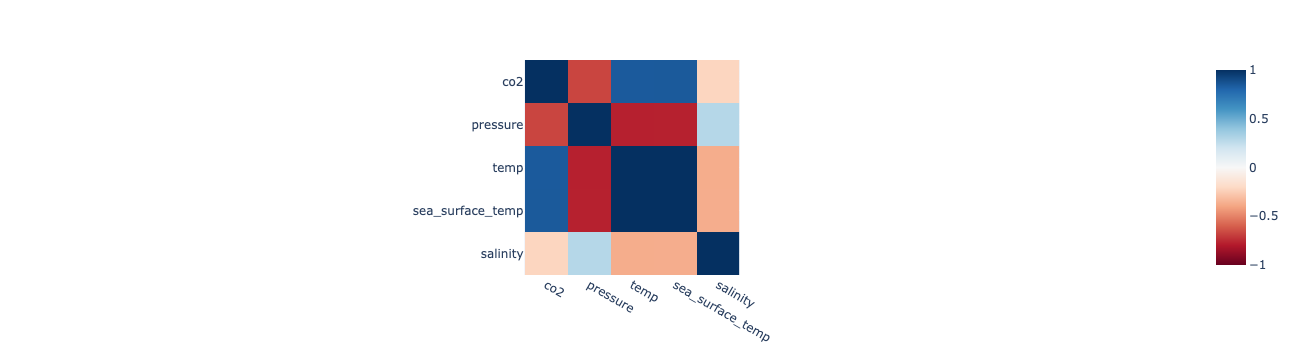

In [12]:
lr_corr_fig = px.imshow(lr_df.corr(), color_continuous_scale = 'RdBu',zmin=-1, zmax=1) # check the documentation!! 
lr_corr_fig.show()

#### Visualise correlations

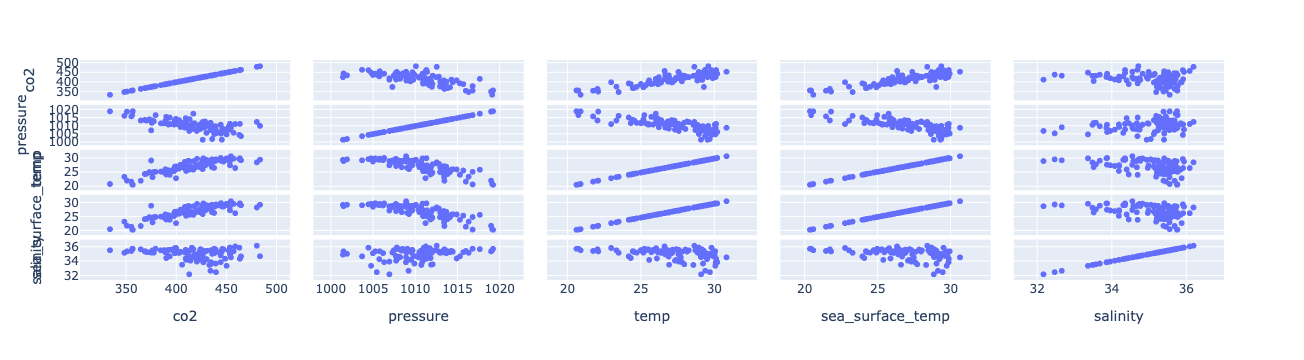

In [13]:
lr_corr_mt = px.scatter_matrix(lr_df)
lr_corr_mt.show()

#### Select domain features - independent variables

In [14]:
X_data = lr_df[['pressure', 'sea_surface_temp']] #'salinity']]
X_data

,pressure,sea_surface_temp
0,1014.35,25.837
1,1009.49,27.639
2,1011.31,26.365
3,1010.93,29.821
4,1006.38,29.900
...,...,...
95,1011.29,26.951
96,1010.45,27.515
97,1014.97,25.916
98,1009.51,27.429


#### Select range feature - dependent variable

In [15]:
y_data = lr_df['co2']
y_data

0     413.36
1     404.38
2     458.92
3     444.49
4     444.45
       ...  
95    410.36
96    426.66
97    409.53
98    429.31
99    393.61
Name: co2, Length: 100, dtype: float64

#### Create train/test data

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, shuffle=True, train_size=0.8, random_state=99)

#### Create the model and fit to training data

In [17]:
linear_model = LinearRegression() 
linear_model.fit(X_train, y_train) 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### Use the model to predict based on the test features

In [18]:
linear_predictions = linear_model.predict(X_test) 
linear_predictions # predicted CO2

array([440.95171019, 395.74544318, 397.8733329 , 439.88285693,
       420.19928893, 417.61709133, 438.13852912, 419.63495793,
       441.07140773, 455.87356135, 434.95373605, 420.17722752,
       433.59883929, 438.577158  , 410.35265387, 444.35659106,
       413.42481514, 426.5170755 , 407.09323337, 404.1179972 ])

In [19]:
lr_R2 = r2_score(y_test, linear_predictions) 
print(f'The model R squared score is: {lr_R2}')

The model R squared score is: 0.4067885693855753


The R-squared is a coeficient between 0 and 1 that determine the quality of the model prediction. This number indicates the percentage of variance in the dependent variable that the independent variables explain. 0 means that the model's prediction is not explained at all by the independent variables, while 1 means that the model's prediction is 100% explained by the independent variables. What does the $r^2$ score above tell us?

#### Visualise the predictions vs actual values (for test data)

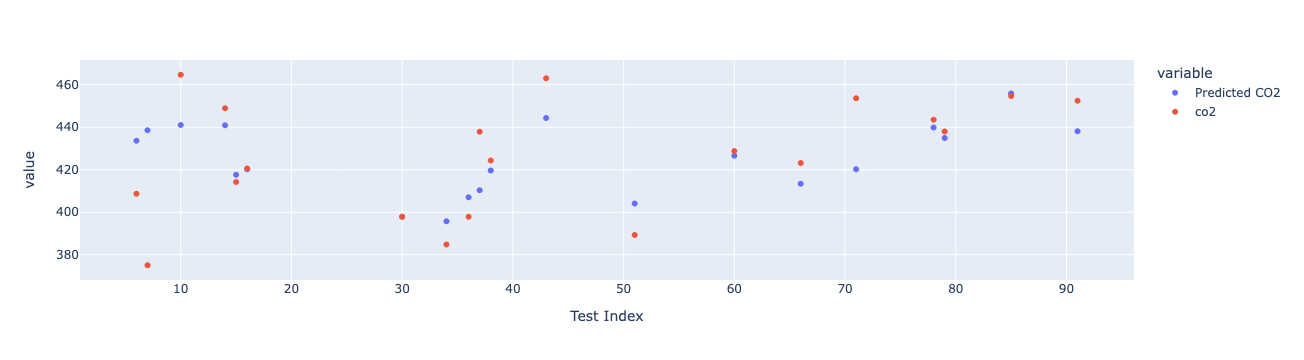

In [20]:
# Create a chart to check the differences between what has been predicted and the real values

y_test_fig_df = pd.DataFrame(y_test)
linear_prediction_fig_df = pd.DataFrame(linear_predictions)
linear_prediction_fig_df.columns = ['Predicted CO2']
linear_prediction_fig_df['Test Index'] = y_test_fig_df.index
linear_prediction_fig_df.set_index('Test Index', inplace=True)
linear_fig_df = linear_prediction_fig_df.join(y_test_fig_df)
linear_fig = px.scatter(linear_fig_df)
linear_fig.show()

#### Try a prediction on unseen data

In [21]:
new_lr_prediction = linear_model.predict(pd.DataFrame({'pressure': [1009.49], 'sea_surface_temp': [32]})) 
new_lr_prediction

array([469.98287539])

### Logistic Regression algorithm

1. Load the [Thyroid sickness determination dataset](https://www.kaggle.com/datasets/bidemiayinde/thyroid-sickness-determination) data located in the data folder (`health.csv`)
2. Perform logistic regression to predic the class variable (There is a thyroid sickness or not)
3. Change features to improve classification
4. Experiment with predictions

#### Load and clean data

In [23]:
log_df = pd.read_csv('./data/health.csv')
# we want to predict thyroid disease, i.e. if log_df['Class'] is sick or negative
# transform categorical variables into numeric
log_df['sex_n'] = LabelEncoder().fit(log_df['sex']).transform(log_df['sex'])
log_df['class_n'] = LabelEncoder().fit(log_df['Class']).transform(log_df['Class'])
log_df

,age,sex,TSH,T3,TT4,T4U,FTI,Class,sex_n,class_n
0,41,F,1.30,2.5,125.0,1.14,109.0,negative,0,0
1,70,F,0.72,1.2,61.0,0.87,70.0,negative,0,0
2,80,F,2.20,0.6,80.0,0.70,115.0,sick,0,1
3,66,F,0.60,2.2,123.0,0.93,132.0,negative,0,0
4,68,M,2.40,1.6,83.0,0.89,93.0,negative,1,0
...,...,...,...,...,...,...,...,...,...,...
2639,19,F,8.80,2.7,108.0,1.11,97.0,negative,0,0
2640,68,F,1.00,2.1,124.0,1.08,114.0,negative,0,0
2641,74,F,5.10,1.8,112.0,1.07,105.0,negative,0,0
2642,72,M,0.70,2.0,82.0,0.94,87.0,negative,1,0


In [24]:
log_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      2644 non-null   str    
 1   sex      2644 non-null   str    
 2   TSH      2644 non-null   float64
 3   T3       2644 non-null   float64
 4   TT4      2644 non-null   float64
 5   T4U      2644 non-null   float64
 6   FTI      2644 non-null   float64
 7   Class    2644 non-null   str    
 8   sex_n    2644 non-null   int64  
 9   class_n  2644 non-null   int64  
dtypes: float64(5), int64(2), str(3)
memory usage: 206.7 KB


In [25]:
# age should be integer instead of object
log_df['age'].value_counts()

age
59    72
70    69
73    66
55    63
60    63
      ..
91     1
6      1
?      1
94     1
92     1
Name: count, Length: 93, dtype: int64

In [26]:
log_df[log_df['age'].str.isnumeric()==False]

,age,sex,TSH,T3,TT4,T4U,FTI,Class,sex_n,class_n
1390,?,F,0.6,1.5,120.0,0.82,146.0,negative,0,0


In [27]:
log_df['age'].unique()

<StringArray>
[ '41',  '70',  '80',  '66',  '68',  '84',  '71',  '59',  '28',  '63',  '46',
  '81',  '55',  '60',  '73',  '34',  '78',  '37',  '85',  '26',  '58',  '44',
  '48',  '61',  '35',  '83',  '87',  '64',  '77',  '65',  '27',  '54',  '69',
  '74',  '76',  '82',  '39',  '49',  '23',  '62',  '31',  '57',  '50',  '72',
  '75',   '7',  '79',  '51',  '53',  '30',  '38',  '21',  '19',  '24',  '42',
  '15',  '25',  '45',  '32',  '47',   '1',  '16',  '67',  '13',  '10',  '43',
  '29',  '33',  '22',  '18',  '56',  '20',  '36',  '52',  '90',  '40',  '14',
  '86',  '17',  '12',   '4',  '89',   '8',   '5', '455',   '2',  '91',   '6',
   '?',  '88',  '93',  '94',  '92']
Length: 93, dtype: str

In [28]:
log_df = log_df[log_df['age'].str.isnumeric()==True].copy()
log_df['age'] = log_df['age'].astype('int')
log_df = log_df[log_df['age'] < 100]
log_df.info()

<class 'pandas.DataFrame'>
Index: 2642 entries, 0 to 2643
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   age      2642 non-null   int64  
 1   sex      2642 non-null   str    
 2   TSH      2642 non-null   float64
 3   T3       2642 non-null   float64
 4   TT4      2642 non-null   float64
 5   T4U      2642 non-null   float64
 6   FTI      2642 non-null   float64
 7   Class    2642 non-null   str    
 8   sex_n    2642 non-null   int64  
 9   class_n  2642 non-null   int64  
dtypes: float64(5), int64(3), str(2)
memory usage: 227.0 KB


In [29]:
log_df.describe()

,age,TSH,T3,TT4,T4U,FTI,sex_n,class_n
count,2642.000000,2642.000000,2642.000000,2642.000000,2642.000000,2642.000000,2642.000000,2642.000000
mean,52.929599,5.037468,2.001151,107.854845,0.995600,109.437964,0.332702,0.080242
std,18.810167,23.979268,0.823970,35.466601,0.196464,32.478130,0.471270,0.271719
min,1.000000,0.005000,0.050000,2.000000,0.250000,2.000000,0.000000,0.000000
25%,37.000000,0.500000,1.500000,88.000000,0.870000,93.000000,0.000000,0.000000
50%,55.000000,1.300000,2.000000,103.000000,0.980000,107.000000,0.000000,0.000000
75%,69.000000,2.600000,2.300000,124.000000,1.087500,124.000000,1.000000,0.000000
max,94.000000,530.000000,10.600000,430.000000,2.120000,395.000000,1.000000,1.000000


#### Check correlations

In [30]:
log_df.corr(numeric_only=True)

,age,TSH,T3,TT4,T4U,FTI,sex_n,class_n
age,1.000000,-0.045172,-0.266769,-0.057436,-0.188765,0.058642,-0.008676,0.180905
TSH,-0.045172,1.000000,-0.167800,-0.287369,0.068728,-0.331026,-0.041445,-0.008023
T3,-0.266769,-0.167800,1.000000,0.573582,0.458823,0.338470,-0.070414,-0.397426
TT4,-0.057436,-0.287369,0.573582,1.000000,0.440277,0.791356,-0.164390,-0.126958
T4U,-0.188765,0.068728,0.458823,0.440277,1.000000,-0.171939,-0.245178,-0.243339
FTI,0.058642,-0.331026,0.338470,0.791356,-0.171939,1.000000,-0.026618,0.022060
sex_n,-0.008676,-0.041445,-0.070414,-0.164390,-0.245178,-0.026618,1.000000,0.030950
class_n,0.180905,-0.008023,-0.397426,-0.126958,-0.243339,0.022060,0.030950,1.000000


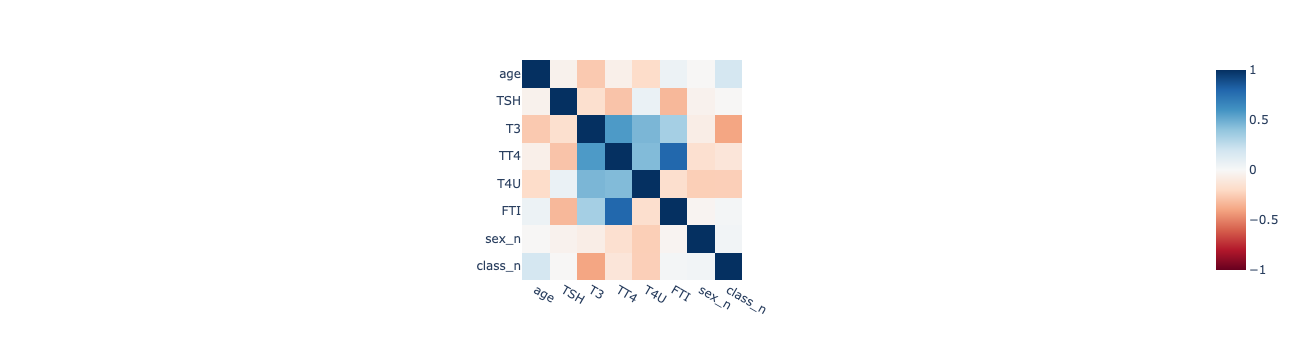

In [31]:
log_corr_fig = px.imshow(log_df.corr(numeric_only=True), color_continuous_scale = 'RdBu', zmin=-1, zmax = 1)
log_corr_fig.show()

#### Select independent and dependent variables

In [32]:
X_data = log_df[['T3', 'TT4', 'T4U']] 
X_data

,T3,TT4,T4U
0,2.5,125.0,1.14
1,1.2,61.0,0.87
2,0.6,80.0,0.70
3,2.2,123.0,0.93
4,1.6,83.0,0.89
...,...,...,...
2639,2.7,108.0,1.11
2640,2.1,124.0,1.08
2641,1.8,112.0,1.07
2642,2.0,82.0,0.94


In [33]:
y_data = log_df['class_n'] 
y_data

0       0
1       0
2       1
3       0
4       0
       ..
2639    0
2640    0
2641    0
2642    0
2643    0
Name: class_n, Length: 2642, dtype: int64

#### Create train/test split, check class balance, and scale

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, shuffle=True, train_size=0.8, random_state=99)

In [35]:
# Check the class balance
y_train.value_counts(normalize=True)

class_n
0    0.918599
1    0.081401
Name: proportion, dtype: float64

Class weights very imbalanced, a lot more negative (healthy) than positive (sick).
There is a class inbalance in the variable that we are going to predict. Therefore, the model is likely to predict towards 'Negative' (healhty) just because the biased data rather than the independent variables. In any classification model such as logistic regression, decision trees, etc. The class balance need to be considered (class_weight input parameter in LogisticRegression function).

Additionally, it is a common practice to scale the date to have a better model. To scale the data wwe are going to use standardization that scale the data to have a mean of 0 and a standard deviation of 1.

In [36]:
scale = StandardScaler()
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

#### Create the model and fit to training data

In [37]:
logistic_model = LogisticRegression(class_weight='balanced') # (class_weight={0: 0.92, 1: 0.07})

In [38]:
# Fit the model to the training dataset
logistic_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

#### Test model on test data and check with confusion matrix

In [39]:
# to evaluate model use confusion matrix
logistic_prediction = logistic_model.predict(X_test)  # Use the model to predict based on the testing dataset
cm = confusion_matrix(y_test, logistic_prediction) # Compare the model's prediction against the true value in the testing dataset
cm

array([[436,  53],
       [  2,  38]])

#### Visualise the confusion matrix

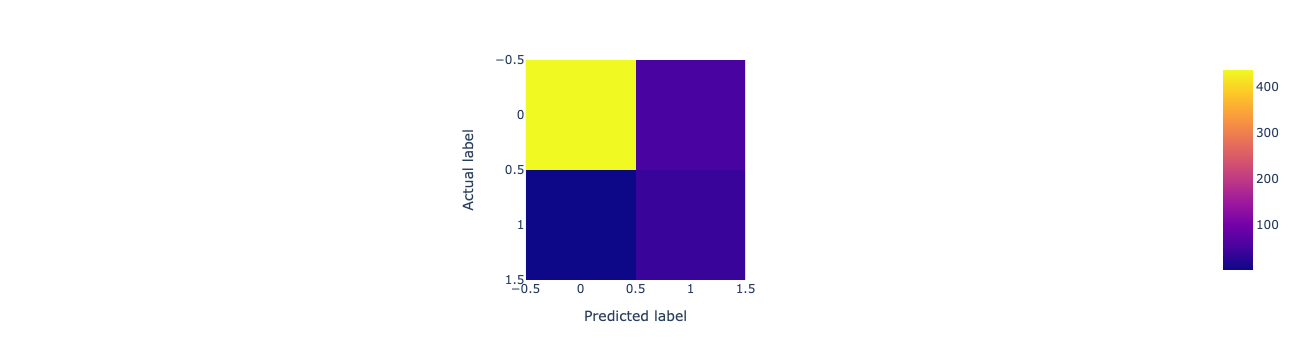

In [40]:
cm_fig = px.imshow(cm, labels={'x': 'Predicted label', 'y': 'Actual label'})
cm_fig.show()

#### Create a test report

In [41]:
report = classification_report(y_test, logistic_prediction)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.89      0.94       489
           1       0.42      0.95      0.58        40

    accuracy                           0.90       529
   macro avg       0.71      0.92      0.76       529
weighted avg       0.95      0.90      0.91       529



Consider precision and recall of model. 

Precision: What proportion of positive identifications was actually correct?
That is: (true positives / (true positives + false positives))

Recall: What proportion of actual positives was identified correctly?
That is (true positives / (true positives + false negatives))

0 means not sick, 1 means sick. 